:::{admonition} Download
:class: important

Download this notebook: **{nb-download}`plot_03_grid_cells.ipynb`**!

:::

In [1]:
%matplotlib inline
import warnings
import jax

jax.config.update("jax_enable_x64", True)

# Ignore the first specific warning
warnings.filterwarnings(
    "ignore",
    message="plotting functions contained within `_documentation_utils` are intended for nemos's documentation.",
    category=UserWarning,
)

# Ignore the second specific warning
warnings.filterwarnings(
    "ignore",
    message="Ignoring cached namespace 'core'",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message=(
        "invalid value encountered in div "
    ),
    category=RuntimeWarning,
)

# Fit grid cell

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pynapple as nap
from scipy.ndimage import gaussian_filter

import nemos as nmo

## Data Streaming

The data used in this tutorial were used in this publication: Sargolini, Francesca, et al. “Conjunctive representation of position, direction, and velocity in entorhinal cortex.” Science 312.5774 (2006): 758-762. The data can be found on the DANDI Archive in [Dandiset 000582](https://dandiarchive.org/dandiset/000582) with DOI https://doi.org/10.48324/dandi.000582/0.251111.2151.

DANDI allows you to stream data without downloading all the files. In this case the data extracted from the NWB file are stored in the nwb-cache folder.

In [3]:
io = nmo.fetch.download_dandi_data(
    "000582",
    "sub-11265/sub-11265_ses-07020602_behavior+ecephys.nwb",
)

## Pynapple

Let's load the dataset and see what's inside

In [4]:
dataset = nap.NWBFile(io.read(), lazy_loading=False)

print(dataset)

07020602
┍━━━━━━━━━━━━━━━━━━━━━┯━━━━━━━━━━┑
│ Keys                │ Type     │
┝━━━━━━━━━━━━━━━━━━━━━┿━━━━━━━━━━┥
│ units               │ TsGroup  │
│ ElectricalSeriesLFP │ Tsd      │
│ SpatialSeriesLED2   │ TsdFrame │
│ SpatialSeriesLED1   │ TsdFrame │
│ ElectricalSeries    │ Tsd      │
┕━━━━━━━━━━━━━━━━━━━━━┷━━━━━━━━━━┙


In this case, the data were used in this [publication](https://www.science.org/doi/full/10.1126/science.1125572).
We thus expect to find neurons tuned to position and head-direction of the animal.
Let's verify that with pynapple.
First, extract the spike times and the position of the animal.

In [5]:
spikes = dataset["units"]  # Get spike timings
position = dataset["SpatialSeriesLED1"]  # Get the tracked orientation of the animal

Here we compute quickly the head-direction of the animal from the position of the LEDs.

In [6]:
diff = dataset["SpatialSeriesLED1"].values - dataset["SpatialSeriesLED2"].values
head_dir = (np.arctan2(*diff.T) + (2 * np.pi)) % (2 * np.pi)
head_dir = nap.Tsd(dataset["SpatialSeriesLED1"].index, head_dir).dropna()

Let's quickly compute some tuning curves for head-direction and spatial position.

In [7]:
hd_tuning = nap.compute_tuning_curves(
    spikes, features=head_dir, bins=61, range=(0, 2 * np.pi), feature_names=["angles"]
)

pos_tuning = nap.compute_tuning_curves(
    spikes, features=position, bins=12, feature_names=["x","y"]
)

Let's plot the tuning curves for each neuron.

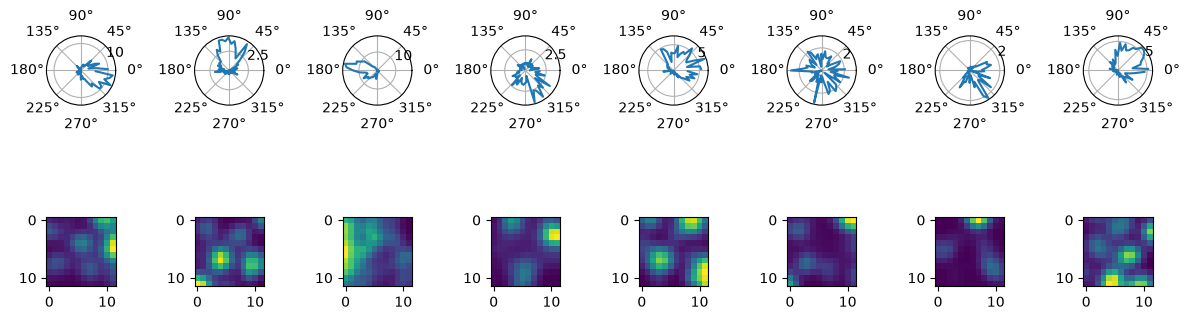

In [8]:
fig = plt.figure(figsize=(12, 4))
gs = plt.GridSpec(2, len(spikes))
for i in range(len(spikes)):
    ax = plt.subplot(gs[0, i], projection="polar")
    ax.plot(hd_tuning[i].angles, hd_tuning[i])

    ax = plt.subplot(gs[1, i])
    ax.imshow(gaussian_filter(pos_tuning[i], sigma=1))
plt.tight_layout()

(grid_cells_nemos)=
## NeMoS
It's time to use NeMoS.
Let's try to predict the spikes as a function of position and see if we can generate better tuning curves
First we start by binning the spike trains in 10 ms bins.

In [9]:
bin_size = 0.01  # second
counts = spikes.count(bin_size, ep=position.time_support)

We need to interpolate the position to the same time resolution.
We can still use pynapple for this.

In [10]:
position = position.interpolate(counts)

We can define a two-dimensional basis for position by multiplying two one-dimensional bases,
see [here](composing_basis_function) for more details.

In [11]:
basis_2d = nmo.basis.BSplineEval(
    n_basis_funcs=10, label="x"
) * nmo.basis.BSplineEval(n_basis_funcs=10, label="y")

# add a label for the multiplicative basis
basis_2d.label = "position"
basis_2d

,label,'position'
,x__bounds,None
,x__fill_value,nan
,x__label,'x'
,x__n_basis_funcs,10
,x__order,4
,x,"'x': BSplineE...s=10, order=4)"
,y__bounds,None
,y__fill_value,nan
,y__label,'y'
,y__n_basis_funcs,10


Let's see what a few basis look like. Here we evaluate it on a 100 x 100 grid.

In [12]:
X, Y, Z = basis_2d.evaluate_on_grid(100, 100)

We can visualize the basis.

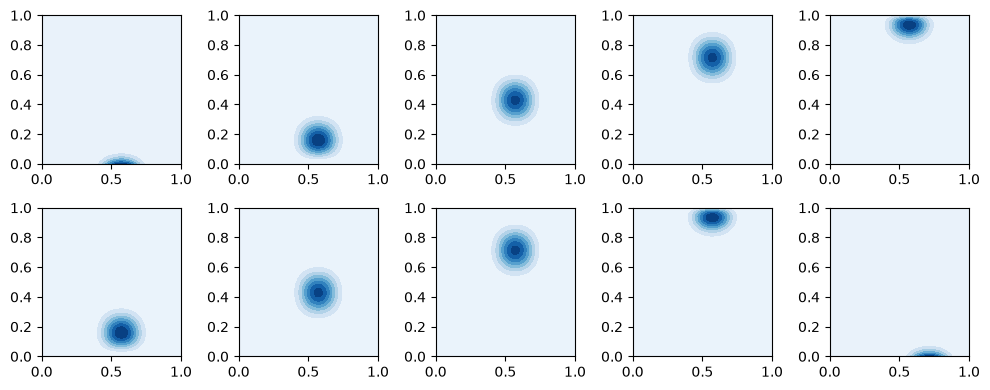

In [13]:
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
for k in range(2):
    for h in range(5):
        axs[k][h].contourf(X, Y, Z[:, :, 50 + 2 * (k + h)], cmap="Blues")

plt.tight_layout()

Each basis element represent a possible position of the animal in an arena.
Now we can "evaluate" the basis for each position of the animal

In [14]:
position_basis = basis_2d.compute_features(position["x"], position["y"])

/home/jenkins/agent/workspace/CCN_nemos_PR-612/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


Now try to make sense of what it is

In [15]:
print(position_basis.shape)

(59998, 100)


The shape is (n_samples, n_basis). This means that for each time point "t", we evaluated the basis at the
corresponding position. Let's plot 5 time steps.

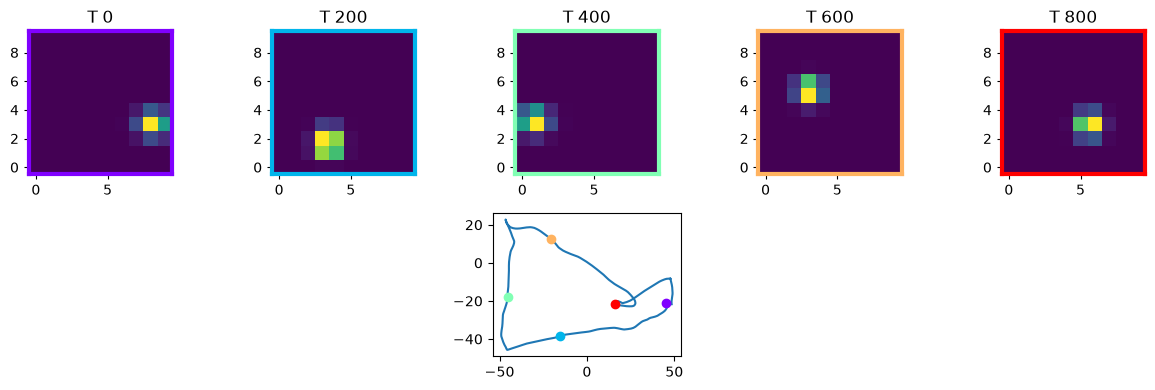

In [16]:
fig = plt.figure(figsize=(12, 4))
gs = plt.GridSpec(2, 5)
xt = np.arange(0, 1000, 200)
cmap = plt.colormaps["rainbow"]
colors = np.linspace(0, 1, len(xt))
for cnt, i in enumerate(xt):
    ax = plt.subplot(gs[0, i // 200])
    ax.imshow(position_basis[i].reshape(10, 10).T, origin="lower")
    for spine in ["top", "bottom", "left", "right"]:
        ax.spines[spine].set_color(cmap(colors[cnt]))
        ax.spines[spine].set_linewidth(3)
    plt.title("T " + str(i))

ax = plt.subplot(gs[1, 2])

ax.plot(position["x"][0:1000], position["y"][0:1000])
for i in range(len(xt)):
    ax.plot(position["x"][xt[i]], position["y"][xt[i]], "o", color=cmap(colors[i]))

plt.tight_layout()

Now we can fit the GLM and see what we get. In this case, we use Ridge for regularization.
Here we will focus on the last neuron (neuron 7) who has a nice grid pattern

In [17]:
model = nmo.glm.GLM(
    regularizer="Ridge",
    regularizer_strength=0.0001,
)

Let's fit the model

In [18]:
neuron = 7

model.fit(position_basis, counts[:, neuron])

,observation_model,PoissonObservations()
,inverse_link_function,<function exp...x7efd23e544a0>
,regularizer,Ridge()
,regularizer_strength,0.0001
,solver_name,'NewtonCholesky'
,solver_kwargs,{}
Name,Type,Value
aux_,NoneType,None
coef_,"ArrayImpl[float64](100,)",Array([-5.369...dtype=float64)
dof_resid_,"ArrayImpl[float64](1,)","Array([59897.], dtype=float64)"
intercept_,"ArrayImpl[float64](1,)",Array([-4.032...dtype=float64)


We can compute the model predicted firing rate.

In [19]:
rate_pos = model.predict(position_basis)

/home/jenkins/agent/workspace/CCN_nemos_PR-612/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


And compute the tuning curves/

In [20]:
model_tuning = nap.compute_tuning_curves(
    rate_pos * rate_pos.rate, features=position, bins=12, feature_names=["x", "y"]
)

Let's compare the tuning curve predicted by the model with that based on the actual spikes.

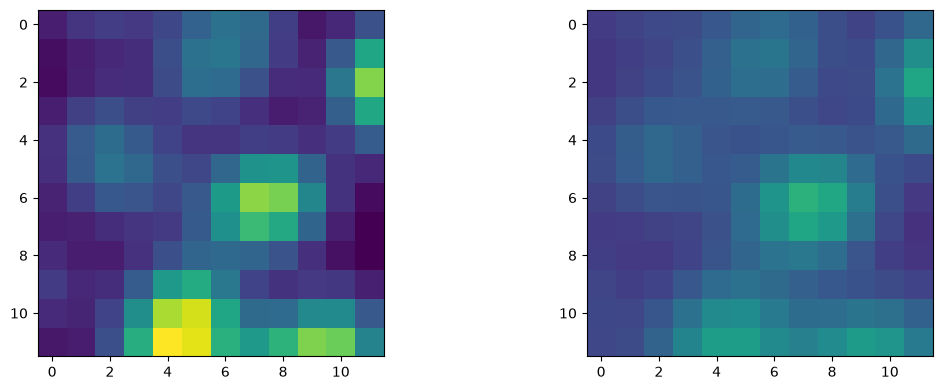

In [21]:
smooth_pos_tuning = gaussian_filter(pos_tuning[neuron], sigma=1)
smooth_model = gaussian_filter(model_tuning[0], sigma=1)

vmin = min(smooth_pos_tuning.min(), smooth_model.min())
vmax = max(smooth_pos_tuning.max(), smooth_model.max())

fig = plt.figure(figsize=(12, 4))
gs = plt.GridSpec(1, 2)
ax = plt.subplot(gs[0, 0])
ax.imshow(smooth_pos_tuning, vmin=vmin, vmax=vmax)
ax = plt.subplot(gs[0, 1])
ax.imshow(smooth_model, vmin=vmin, vmax=vmax)
plt.tight_layout()

The grid shows but the peak firing rate is off, we might have over-regularized.
We can fix this by tuning the regularization strength by means of cross-validation.
This can be done through scikit-learn. Let's apply a grid-search over different
values, and select the regularization by k-fold cross-validation.

In [22]:
# import the grid-search cross-validation from scikit-learn
from sklearn.model_selection import GridSearchCV

# define the regularization strength that we want cross-validate
param_grid = dict(regularizer_strength=[1e-6, 1e-5, 1e-3])

# pass the model and the grid
cls = GridSearchCV(model, param_grid=param_grid)

# run the search, the default is a 5-fold cross-validation strategy
cls.fit(position_basis, counts[:, neuron])

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GLM( obse...tonCholesky' )
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regularizer_strength': [1e-06, 1e-05, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: int, default=0Controls the verbosity of information printed during

Let's get the best estimator and see what we get.

In [23]:
best_model = cls.best_estimator_

Let's predict and compute the tuning curves once again.

In [24]:
# predict the rate with the selected model
best_rate_pos = best_model.predict(position_basis)

# compute the 2D tuning
best_model_tuning = nap.compute_tuning_curves(
    best_rate_pos * best_rate_pos.rate, features=position, bins=12, feature_names=["x", "y"]
)

/home/jenkins/agent/workspace/CCN_nemos_PR-612/venv/lib/python3.12/site-packages/pynapple/core/utils.py:198: UserWarning: Converting 'd' to numpy.array. The provided array was of type 'ArrayImpl'.
  warnings.warn(


We can now plot the results.

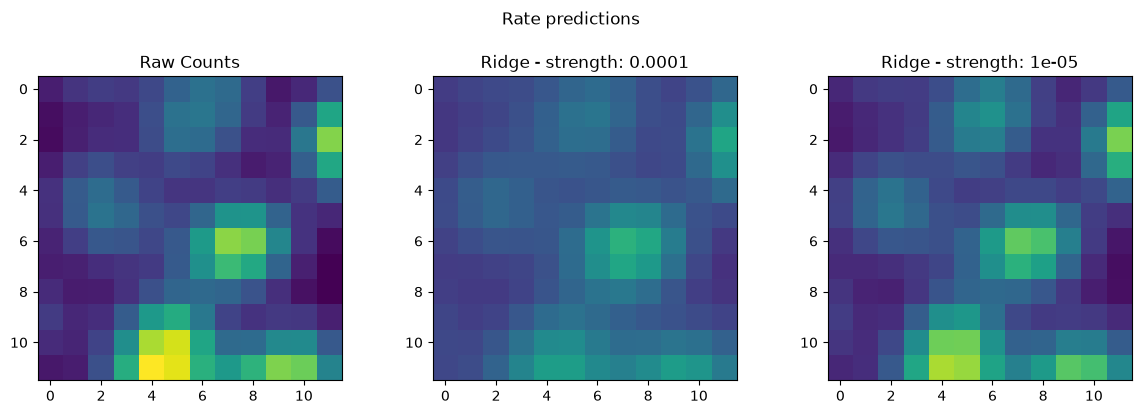

In [25]:
# plot the resutls
smooth_best_model = gaussian_filter(best_model_tuning[0], sigma=1)

vmin = min(smooth_pos_tuning.min(), smooth_model.min(), smooth_best_model.min())
vmax = max(smooth_pos_tuning.max(), smooth_model.max(), smooth_best_model.max())

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
plt.suptitle("Rate predictions\n")
axs[0].set_title("Raw Counts")
axs[0].imshow(smooth_pos_tuning, vmin=vmin, vmax=vmax)
axs[1].set_title(f"Ridge - strength: {model.regularizer_strength}")
axs[1].imshow(smooth_model, vmin=vmin, vmax=vmax)
axs[2].set_title(f"Ridge - strength: {best_model.regularizer_strength}")
axs[2].imshow(smooth_best_model, vmin=vmin, vmax=vmax)
plt.tight_layout()

In [26]:
# save image for thumbnail
from pathlib import Path
import os

root = os.environ.get("READTHEDOCS_OUTPUT")
if root:
   path = Path(root) / "html/_static/thumbnails/tutorials"
# if local store in ../_build/html...
else:
   path = Path("../_build/html/_static/thumbnails/tutorials")

# make sure the folder exists if run from build
if root or Path("../assets/stylesheets").exists():
   path.mkdir(parents=True, exist_ok=True)

if path.exists():
  fig.savefig(path / "plot_03_grid_cells.svg")